In [ ]:
# Modules used for KNN implementation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image, display

In [ ]:
# Functions for reading the data and validating classes

def readXY(file_name, head=None): # read data from CSV and return numpy array, default to no header
  read_df = pd.read_csv(file_name, header=head)
  return read_df.to_numpy() # X and y are kept in same array

def validateXY(XY, y_allowed):
    
  X = np.asarray(XY[:, :-1], dtype=float) # define X as all columns except last
  y = XY[:, -1] # define y as last column

  valid_X = np.all(np.isfinite(X), axis=1) # keeps only finite, numeric X values
  valid_y = np.isin(y, list(y_allowed)) # keeps only y values in the allowed y list
  valid_XY = valid_X & valid_y

  return XY[valid_XY] # removes invalid rows

In [70]:
# Getting the data

XY_data = readXY("Prog1data.csv") # get X and y from csv file
print("-"*25)
print("Data imported. Dataset size:", XY_data.shape)
# cleans data such that X is all numeric and finite values and y contains only "+" or "-"
XY_cleaned = validateXY(XY_data, {"+", "-"})
n_removed = XY_data.shape[0] - XY_cleaned.shape[0] # number of instances removed during cleaning
print("-"*25)
print("Cleaning:", n_removed, "instance(s) removed")

-------------------------
Data imported. Dataset size: (2000, 12)
-------------------------
Cleaning: 1 instance(s) removed


In [71]:
# Function for determining the representation of each class in the dataset

def count_classes(y, classes):

  class_counts = {}
  class_percents = {}
  for c in classes:
    class_counts[c] = np.sum(y == c) # dictionary with number of instances of each class
    class_percents[c] = class_counts[c] / len(y) # dictionary with percent of dataset represented by each class
  
  return class_counts, class_percents

In [72]:
# Understanding the class splits

label_counts, label_percents = count_classes(XY_cleaned[:, -1], {"+", "-"})
for label, pct in label_percents.items():
    print(f"{label}: {pct * 100:.3f}%")

+: 49.975%
-: 50.025%


In [73]:
# Function for partitioning the data into train and test sets

def train_test_splits(XY, split_ratio): # split data into train and test sets, expects X and y data in same array

  rng = np.random.default_rng(713) # sets seed for reproducibility between runs
  rng.shuffle(XY) # randomly shuffle the data
  
  X = XY[:, :-1] # define X as all columns except last
  y = XY[:, -1] # define y as last column

  if split_ratio > 1 or split_ratio < 0: # split ratio must be between 0-1 because it is treated as a percentage
    raise ValueError("Split ratio must be between 0 and 1") # error handling for split ratio

  split_idx = int(len(X) * split_ratio) # calculate index to split at
  X_train, X_test = X[:split_idx], X[split_idx:] # split X into train and test sets
  y_train, y_test = y[:split_idx], y[split_idx:] # split y into train and test sets

  return X_train, X_test, y_train, y_test

In [74]:
# Partitioning the data

# split data into train and test sets, 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_splits(XY_cleaned, 0.8)
print("Training Set Size:", X_train.shape)
print("Test Set Size:", X_test.shape)
train_counts, train_percents = count_classes(y_train, {"+", "-"})
test_counts, test_percents = count_classes(y_test, {"+", "-"})
print("Training Split:")
for label, pct in train_percents.items():
    print(f"{label}: {pct * 100:.3f}%")
print("Test Split:")
for label, pct in test_percents.items():
    print(f"{label}: {pct * 100:.3f}%")

Training Set Size: (1599, 11)
Test Set Size: (400, 11)
Training Split:
+: 50.031%
-: 49.969%
Test Split:
+: 49.750%
-: 50.250%


In [75]:
# Euclidean distance function

def euclidean_distance(x1, x2): # calculate euclidean distance between two points
  return np.sqrt(np.sum((x1 - x2) ** 2)) # using numpy to calculate distance between all elements of the array

In [76]:
# KNN Class

class KNN_euclidean:

  def __init__(self, k=5): # default to 5 nearest neighbors
    self.k = k

  def train(self, X, y): # computation happens at prediction time, training just involves storing the data
    self.X_train = X
    self.y_train = y

  def predict(self, new_data): # predicts class for array of new data points
    predictions = [self.predict_class(new_point) for new_point in new_data]
    return np.array(predictions)

  def predict_class(self, new_point): # predicts class for single new data point

    # calculate euclidean distance between new point and all points in training data
    distances = [euclidean_distance(point, new_point) for point in self.X_train]
    
    # get indices for k nearest neighbors
    # if k > data points in training set, use all available data points in training set
    kn_idxs = np.argsort(distances)[:min(self.k, len(self.X_train))]
    kn_classes = [self.y_train[idx] for idx in kn_idxs] # get classes for k nearest neighbors in training data

    counts = {}
    for neighbor_class in kn_classes: # handles more than just +/- classes
      counts[neighbor_class] = counts.get(neighbor_class,0) + 1 # count votes per classes in the k nearest neighbors
    
    return max(counts, key=counts.get) # return class with greatest number of votes in the k nearest neighbors

In [77]:
# Euclidean KNN Training and Prediction
euclidean_model = KNN_euclidean()
euclidean_model.train(X_train, y_train) # train model with training set
y_pred = euclidean_model.predict(X_test) # predict classes for test set

In [78]:
# Functions for determining evaluation metrics

def binary_metrics_counts(y_true, y_pred):

  if y_true.shape != y_pred.shape:
      raise ValueError("y and y predicted are different lengths") # error handling to ensure y and y_pred correspond
      
  metric_counts = {
      "tp": 0,
      "tn": 0,
      "fp": 0,
      "fn": 0
  }

  for idx, true_label in enumerate(y_true):
    if y_pred[idx] == "+":
      if true_label == "+": # indicates a true positive result
        metric_counts["tp"] += 1
      else: # indicates a false positive result
        metric_counts["fp"] += 1
    else:
      if true_label == "-": # indicates a true negative result
        metric_counts["tn"] += 1
      else: # indicates a false negative result
        metric_counts["fn"] += 1

  return metric_counts

def binary_metrics(y_true, y_pred):

  # gets counts of true positive, true negative, false positive, false negative
  metric_counts = binary_metrics_counts(y_true, y_pred)
  tp = metric_counts.get("tp")
  tn = metric_counts.get("tn")
  fp = metric_counts.get("fp")
  fn = metric_counts.get("fn")

  accuracy = (tp + tn) / (tp + tn + fp + fn) # accuracy calculation
  precision = tp / (tp + fp) # precision calculation
  recall = tp / (tp + fn) # recall calculation
  f1 = 2 * ((precision * recall) / (precision + recall)) # f1 score calculation

  return accuracy, precision, recall, f1

In [79]:
# Evaluation Metrics
euc_accuracy, euc_precision, euc_recall, euc_f1 = binary_metrics(y_test, y_pred) # metrics for euclidian KNN
print("-"*25)
print("Minimum Implementation KNN Metrics:",
"\nk:", euclidean_model.k,
"\nAccuracy:", round(euc_accuracy, 5),
"\nPrecision:", round(euc_precision, 5),
"\nRecall:", round(euc_recall, 5),
"\nF1:", round(euc_f1,5))
print("-"*25)

-------------------------
Minimum Implementation KNN Metrics: 
k: 5 
Accuracy: 0.98 
Precision: 0.98477 
Recall: 0.97487 
F1: 0.9798
-------------------------


In [80]:
# Functions to construct the confusion matrix

def confusion_matrix(y_true, y_pred, labels):

  # creates nxn matrix where each label corresponds to a column and row
  cm = np.zeros((len(labels), len(labels)), dtype=int)
  label_idx = {label: i for i, label in enumerate(labels)} # numerically defines labels

  for true, pred in zip(y_true, y_pred):
    cm[label_idx[true], label_idx[pred]] += 1 # counts true value vs. predicted value
  
  return cm

def plot_cm(cm, labels): # plot the confusion matrix
  fig, ax = plt.subplots()

  for i in range(len(labels)):
    for j in range(len(labels)):
      color = "lightgreen" if i == j else "lightcoral" # green for correct labels, red for incorrect
      rect = Rectangle((j-0.5, i-0.5), 1, 1, facecolor=color, edgecolor="black")
      ax.add_patch(rect)
      ax.text(j, i, cm[i,j], ha="center", va="center")
  
  ax.set_xlim(-0.5, len(labels) -0.5)
  ax.set_ylim(len(labels) - 0.5, -0.5)
  
  ax.set_xticks(np.arange(len(labels)))
  ax.set_yticks(np.arange(len(labels)))
  ax.set_xticklabels(labels)
  ax.set_yticklabels(labels)

  ax.set_xlabel("Predicted label")
  ax.set_ylabel("True label")
  ax.set_title("Confusion Matrix")

  plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
  plt.tight_layout()
  plt.show()

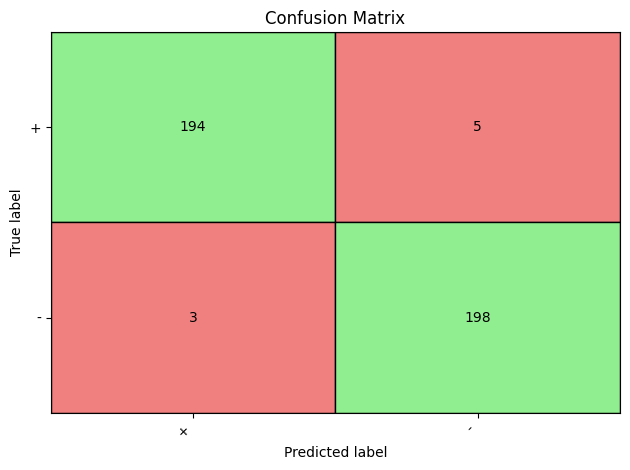

In [81]:
cm = confusion_matrix(y_test, y_pred, {"+", "-"})
plot_cm(cm, {"+", "-"})

In [82]:
# Implementing user-specified k values

# asks for 3 k values to test
k_values = [int(k.strip()) for k in input("Enter 3 values for k, separated by commas: ").split(",")]

for k in k_values: # train a new classifier for each user specified k
  model = KNN_euclidean(k=k)
  model.train(X_train, y_train) # uses same training data for each model
  preds = model.predict(X_test) # uses same test data for each model
  a, p, r, f1 = binary_metrics(y_test, preds) # evaluation metrics
  print("-"*25)
  print("K = ", k,
  "\nAccuracy:", round(a, 5),
  "\nPrecision:", round(p, 5),
  "\nRecall:", round(r, 5),
  "\nF1:", round(f1,5))
  print("-"*25)

Enter 3 values for k, separated by commas:  15,25,35


-------------------------
K =  15 
Accuracy: 0.9725 
Precision: 0.98454 
Recall: 0.9598 
F1: 0.97201
-------------------------
-------------------------
K =  25 
Accuracy: 0.9725 
Precision: 0.98454 
Recall: 0.9598 
F1: 0.97201
-------------------------
-------------------------
K =  35 
Accuracy: 0.9675 
Precision: 0.98438 
Recall: 0.94975 
F1: 0.96675
-------------------------


In [83]:
# Handling more classes

# Loading the Iris dataset
XY_iris = readXY("Iris.csv", 0) # get the X and y data, exclude header row
XY_iris = XY_iris[:, 1:] # removes first column as it is an ID column
print("-"*25)
print("Data imported. Dataset size:", XY_iris.shape)
iris_labels = {"Iris-setosa", "Iris-versicolor", "Iris-virginica"}
# clean data such that X is all numeric and y only contains proper classes
XY_iris_cleaned = validateXY(XY_iris, iris_labels)
n_removed_iris = XY_iris.shape[0] - XY_iris_cleaned.shape[0] # number of instances removed during cleaning
print("-"*25)
print("Cleaning:", n_removed_iris, "instance(s) removed")

-------------------------
Data imported. Dataset size: (150, 5)
-------------------------
Cleaning: 0 instance(s) removed


In [84]:
# Understanding the class splits

label_counts_iris, label_percents_iris = count_classes(XY_iris_cleaned[:, -1], iris_labels)
for label, pct in label_percents_iris.items():
    print(f"{label}: {pct * 100:.3f}%")

Iris-versicolor: 33.333%
Iris-virginica: 33.333%
Iris-setosa: 33.333%


In [85]:
# Partitioning the data

# split data into train and test sets, 80% train and 20% test
print("-"*25)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_splits(XY_iris_cleaned, 0.8)
print("Training Set Size:", X_iris_train.shape)
print("Test Set Size:", X_iris_test.shape)
print("-"*25)
iris_train_counts, iris_train_percents = count_classes(y_iris_train, iris_labels)
iris_test_counts, iris_test_percents = count_classes(y_iris_test, iris_labels)
print("Training Split:")
for label, pct in iris_train_percents.items():
    print(f"{label}: {pct * 100:.3f}%")
print("-"*25)
print("Test Split:")
for label, pct in iris_test_percents.items():
    print(f"{label}: {pct * 100:.3f}%")

-------------------------
Training Set Size: (120, 4)
Test Set Size: (30, 4)
-------------------------
Training Split:
Iris-versicolor: 34.167%
Iris-virginica: 33.333%
Iris-setosa: 32.500%
-------------------------
Test Split:
Iris-versicolor: 30.000%
Iris-virginica: 33.333%
Iris-setosa: 36.667%


In [86]:
# Function for determining accuracy from the confusion matrix

def accuracy(cm): # calculate accuracy from confusion matrix
  return np.trace(cm) / np.sum(cm)

In [87]:
# Euclidean KNN Implementation and Evaluation
# Analysis of accuracy by k values from 5-115 (note entire training set size is only 120 instances)

iris_train_accuracy = {} # dictionary to store train accuracy by k value
iris_test_accuracy = {} # dictionary to store test accuracy by k value

for k in range(5, 116, 10): # iterate from k=5 to k=115, incrementing by 10

  iris_model = KNN_euclidean(k)
  iris_model.train(X_iris_train, y_iris_train) # train model with training set
  
  y_iris_train_pred = iris_model.predict(X_iris_train) # predict classes for training set
  y_iris_test_pred = iris_model.predict(X_iris_test) # predict classes for test set
  
  train_cm_iris = confusion_matrix(y_iris_train, y_iris_train_pred, iris_labels)
  test_cm_iris = confusion_matrix(y_iris_test, y_iris_test_pred, iris_labels)
  
  iris_train_accuracy[k] = accuracy(train_cm_iris) # append training accuracy for the given k value to the dictionary
  iris_test_accuracy[k] = accuracy(test_cm_iris) # append test accuracy for the given k value to the dictionary

In [88]:
# Function for plotting accuracy

def plot_accuracy(train_accuracy, test_accuracy):

  k_values_train = sorted(train_accuracy.keys()) # sorted k values for training evaluation
  accuracies_train = [train_accuracy[k] for k in k_values_train] # corresponding accuracies for training evaluation

  k_values_test = sorted(test_accuracy.keys()) # sorted k values for training evaluation
  accuracies_test = [test_accuracy[k] for k in k_values_test] # corresponding accuracies for training evaluation

  plt.plot(k_values_train, accuracies_train, marker='o', label='Training Accuracy')
  plt.plot(k_values_test, accuracies_test, marker='o', label='Test Accuracy')

  plt.xlabel("k value")
  plt.ylabel("Accuracy")
  plt.title("KNN: k value vs Accuracy")
  plt.xticks(np.arange(5, max(max(k_values_train), max(k_values_test)) + 10, 10))
  plt.legend()
  plt.show()

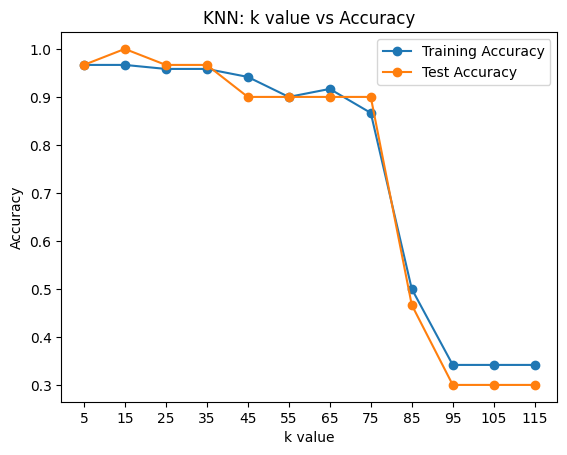

In [89]:
plot_accuracy(iris_train_accuracy, iris_test_accuracy)

----------------------------------------------------------------------------------
# Discussion Report

### Overview
K-Nearest Neighbors (KNN) is a classification technique used to predict the class of a data point based on the classes of the “K” number of data points in the training set closest to the data point of interest: the K-nearest neighbors (KNNs) (GRAD504, 2026). For categorical data, class prediction is a simple majority vote of the KNNs (GRAD504, 2026). Regression can be performed on numeric data such that the predicted value is the mean of the KNNs (GRAD504, 2026).

The defined number of neighbors (K) used in prediction determines the decision boundary of each prediction. As shown in Figure 1, lower K values complicate the decision boundary, and models with lower K values are more sensitive to noise such that erroneous data may yield false predictions for new data points (GRAD504, 2026). However, while higher K values simplify the decision boundary and reduce noise sensitivity, there can be an impact on accuracy as the overall majority class of the training set is predicted for most new data points (GRAD504, 2026). In defining K, Occam’s Razor should be applied to capture sufficient complexity while using the simplest model possible (GRAD504, 2026).

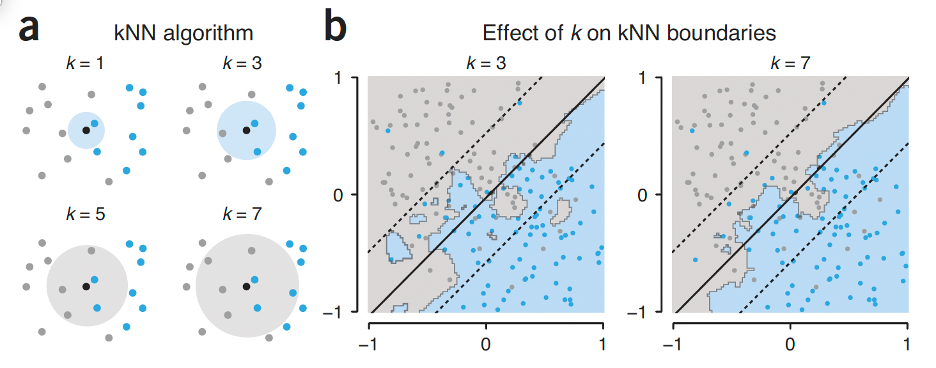

In [92]:
# Figure 1: Decision Boundary by K Value (Bzdok et al., 2018)
display(Image(filename="KNN_boundaries.png"))

A variety of distance metrics can be deployed to determine the KNNs of a given input data point. The equation below shows the Euclidean distance formula, which is one of the most common distance metrics used for continuous data in KNN (GRAD504, 2026).

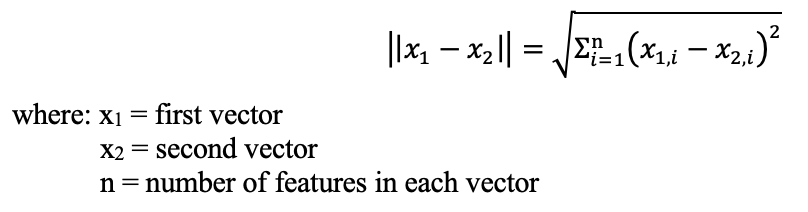

In [94]:
# Equation 1 (GRAD504, 2026)
display(Image(filename="euclidean_distance.png"))

### KNN Implementation
#### Binary Class Prediction
Before developing the KNN, the dataset was cleaned to ensure class values were of the allowed classes (validateXY). For the initial implementation using the data included in Prog1data.csv, the allowed classes were either “+” or “-”. Cleaning involved the removal of one instance with an invalid class label. Of the remaining instances, 49.975% were of the “+” class, and 50.025% were of the “-” class (count_classes).

The KNN class (KNN_euclidean) was developed with 3 critical functions for model training (train), predicting classes of individual data points (predict_class), and for predicting classes of multiple new data points (predict). Training the KNN classifier involves storing all data points from the training set. For the initial implementation using the provided Prog1data.csv, the data was divided such that 80% (1599 instances) was used for training with the remaining 20% (400 instances) for testing. The instances were randomized before dividing into the training and test sets (train_test_splits). As shown in Table 1, both the training and test sets were representative of the overall representation of each class in the dataset.

*Table 1: Binary KNN Classifier Dataset Class Splits*

| Class | Overall Dataset | Training Set | Test Set |
|:------|----------------:|-------------:|---------:|
| +     | 49.975%         | 50.031%      | 49.750%  |
| -     | 50.025%         | 49.969%      | 50.250%  |

For predicting, the Euclidean distance function (euclidean_distance) was implemented as the distance metric. Prediction requires calculating the distance between every point of the training set and an input data point to determine the KNNs. Error handling was implemented so that if the chosen K value exceeded the number of items in the training set, all training instances were used for prediction. Evidently, computation happens during prediction, resulting in longer processing times for each prediction compared to some other classification techniques, like neural networks where the bulk of computation occurs during model training (GRAD504, 2026). Based on the implementation using the provided Prog1data.csv, the KNN classifier with Euclidean distance takes about 0.8 seconds to make a prediction for a single new data point and about 4.5 seconds to make a prediction on all 400 instances in the test set. The training dataset used is relatively small, yet the prediction time is still considerable. In real-world applications, training sets are often much larger, which would further increase computation time during prediction. In applications like autonomous driving and real-time cybersecurity threat mitigation where prediction speed is critical to safety, KNNs are likely not an appropriate machine learning technique.

The test set accuracy, precision, recall, and the F1 score of the binary KNN classifier are shown in Table 2. With the even split between “+” and “-” classes, accuracy is an appropriate performance metric and results suggests KNN is a good fit for this dataset (GRAD504, 2026). This is also reflected in the confusion matrix for the test set with K=5 (Figure 2). Precision indicates that when a given class is predicted, it is the correct class 98.477% of the time when K=5, and recall indicates out of all the instances of a given class, 97.487% were classified correctly when K=5. The high F1 score reflects both the high precision and high recall. As K increases, all evaluation metrics indicate a poorer model fit, with recall showing the greatest decline. However, the decline in performance metrics is subtle, with no change between K=15 and K=25, suggesting that a higher K value could be used for this dataset to reduce computational cost with minimal impact on performance.

*Table 2: Binary KNN Classifier Evaluation Metrics*

| Metric   | K=5    | K=15   | K=25   | K=35   |
|:---------|-------:|-------:|-------:|-------:|
| Accuracy | 0.98   | 0.9725 | 0.9725 | 0.9675 |
| Precision| 0.98477| 0.98454| 0.98454| 0.98438|
| Recall   | 0.97487| 0.9598 | 0.9598 | 0.94975|
| F1       | 0.9798 | 0.97201| 0.97201| 0.96675|

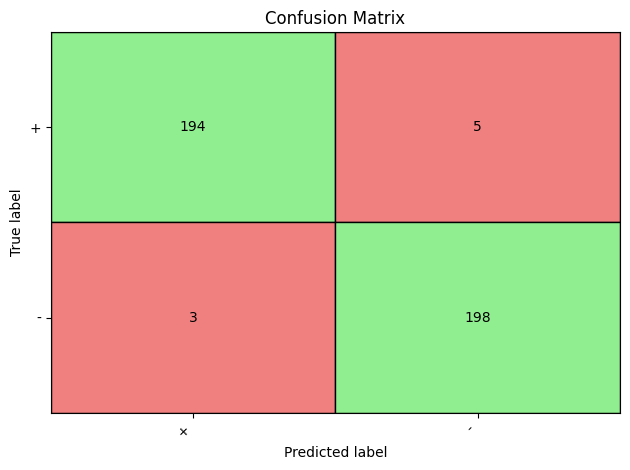

In [97]:
# Figure 2: Binary KNN Classifier Confusion Matrix (K=5)
plot_cm(cm, {"+", "-"})

#### Multiclass Prediction
The Iris dataset (Iris.csv) was used to assess KNN performance with more than two class labels. The functions described for the binary KNN classifier were designed to support multiclass classification in addition to binary. Again, the dataset was cleaned to remove instances with invalid class labels (validateXY). The valid classes were defined as “iris-setosa,” “iris-versicolor,” and “iris-virginica.” All instances had valid classes in the Iris dataset. Class analysis (count_classes) indicated an even split with 33.333% of instances represented by each class.

A new KNN classifier was defined using the same Euclidean KNN class (KNN_euclidean) as described previously. The dataset was again randomly shuffled and divided to use 80% (120 instances) as the training set and 20% (30 instances) as test set (train_test_splits). As shown in Table 3, the training and test sets were representative of the overall representation of each class in the dataset.

*Table 3: Multiclass KNN Classifier Dataset Class Splits*

| Class            | Overall Dataset | Training Set | Test Set |
|:-----------------|----------------:|-------------:|---------:|
| Iris-setosa      | 33.333%         | 32.500%      | 36.667%  |
| Iris-versicolor  | 33.333%         | 34.167%      | 30.000%  |
| Iris-virginica   | 33.333%         | 33.333%      | 33.333%  |

For prediction, Euclidean distance was used to identify the KNNs with the same error handling for if the K value exceeded the number of items in the training set. Given the balanced class distribution, accuracy is an appropriate evaluation metric (GRAD504, 2026). If the dataset had been imbalanced, precision and recall would have been preferable as accuracy may otherwise have provided a misleading assessment of performance (GRAD504, 2026). Figure 3 shows accuracy plotted against K value. As shown, accuracy remains fairly stable for values of K between 5 and 75, suggesting that K could be increased as high as 75 to reduce computational cost without substantially affecting accuracy. However, when K is increased above 75, accuracy for both the training and test sets drops dramatically to around 30% when K=95. Increasing K too high causes the prediction to depend more on the overall class distribution of the training set than the local neighborhood of each point. Because “iris-versicolor” represents the greatest percent of the training set, as K increases, the model likely predicts that class for most predictions. This reduces accuracy toward approximately one third, which is the expected accuracy of always predicting a single class in a balanced three class dataset.

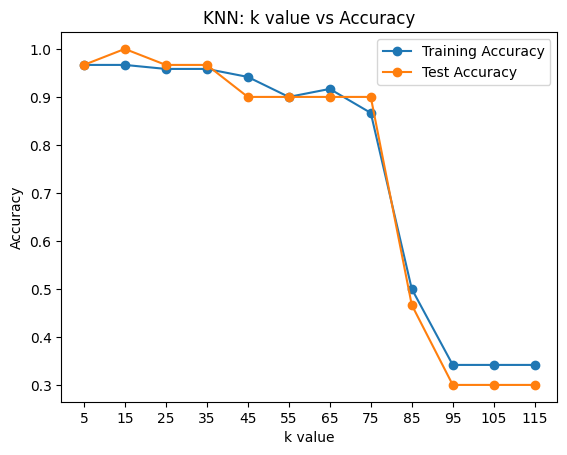

In [98]:
# Figure 3: Multiclass KNN Classifier Accuracy by K Value
plot_accuracy(iris_train_accuracy, iris_test_accuracy)

### Discussion
The discussed implementation used a brute-force approach to identify the KNNs, which involves calculating the distance between all pairs of points in the dataset. As the number of samples (N) and dimensions (D) of the dataset grows, computation scales by DN^2, such that this approach quickly becomes infeasible for large, high-dimensional datasets (scikit-learn, 2026).

The K-D tree data structure offers faster indexing for more efficient searches on large, high-dimensional datasets (scikit-learn, 2026). The required number of distance calculations is reduced by encoding aggregate distance information for the sample (scikit-learn, 2026). K-D trees use a binary tree structure that recursively partitions data along cartesian axes to divide the data into orthotropic regions (scikit-learn, 2026). The partitioning process is quick as the data is only divided along data axes rather than using higher dimensional distances (scikit-learn, 2026). The use of the median value for splitting regions as well as shrinking the data space to the actual data range offer further efficiencies in search but require more complicated model construction (SciPy, 2008). With K-D trees, computation scales by DNlog(N) (where D = dimensions and N = number of samples), which is a significant reduction compared to brute-force searches (scikit-learn, 2026). For datasets of less than 20-dimensions, K-D trees offer significant advantages over brute-force search, but as dimensions grow, K-D trees experience similar inefficiencies to brute-force (SciPy, 2008). The dataset used for the binary KNN classifier involved 11-dimenions, and the Iris dataset used for the multiclass KNN classifier involved only 4-dimensions. The use of K-D trees would therefore offer computational efficiency compared to the brute-force search that was used for the implementation described in this report.

Ball trees address the inefficiencies of K-D trees for higher-dimensional data (scikit-learn, 2026). While K-D trees partition along cartesian axes, ball trees divide the data in a series of nested hyper-spheres, offering more efficient searches on structured, high-dimensional data (scikit-learn, 2026). Tree construction is more computationally costly than K-D trees but significantly reduces the number of candidate points for each search (scikit-learn, 2026). A single distance calculation between the test point and centroid of the ball tree determines the lower and upper boundary on the distance from the test point to all points in the node (scikit-learn, 2026). For both the binary and multiclass KNN classifiers, the datasets were low-dimensional enough that a K-D tree should be efficient, making ball trees unnecessary for the applications discussed in this report.

On a typical workstation of 5GHz CPU, 128GB RAM, computation time is reasonable for the relatively small, low-dimensional datasets used to train the binary and multiclass KNN classifiers (~0.8 seconds per prediction for the binary KNN classifier). However, applications that require near real-time predictions would likely demand greater computational resources and more efficient data structures. Whether using brute-force or more advanced tree structures for KNN identification, computational cost increases substantially with dataset size and dimensionality, making deployment on a typical workstation impractical for large-scale or highly dimensional problems.

### References
Bzdok, D., Krzywinski, M., & Altman, N. (2018). Machine learning: supervised methods SVM and kNN. Nature Methods, 15(1), 5–6. https://doi.org/10.1038/nmeth.4551 

Clifton, C. (2026a). 1.08 - AI as functions and signal processing. Purdue University. Purdue University. Retrieved March 11, 2026, from https://purdue.brightspace.com/d2l/le/content/1493044/viewContent/21344436/View. 

Clifton, C. (2026b). 3.04 - AI as ML: K-nearest neighbor. Purdue University. Purdue University. Retrieved March 23, 2026, from https://purdue.brightspace.com/d2l/le/content/1493044/viewContent/21344456/View. 

Clifton, C. (2026c). 3.05 - K-nearest neighbor: K value. Purdue University. Purdue University. Retrieved March 23, 2026, from https://purdue.brightspace.com/d2l/le/content/1493044/viewContent/21344479/View. 

Clifton, C. (2026d). 3.06 - K-nearest neighbor: implementation. Purdue University. Purdue University. Retrieved March 23, 2026, from https://purdue.brightspace.com/d2l/le/content/1493044/viewContent/21344480/View. 

Faiss. (n.d.). Welcome to FAISS documentation. Welcome to Faiss Documentation - Faiss documentation. https://faiss.ai/index.html 

scikit-learn. (2026a). 1.6. nearest neighbors. scikit learn. https://scikit-learn.org/stable/modules/neighbors.html 

scikit-learn. (2026b). BallTree. scikit learn. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.BallTree.html#sklearn.neighbors.BallTree 

SciPy. (2008). KDTree. https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html 